# Stage 4: RL LOD Policy Training — REINFORCE

Trains a Gaussian policy network on rollout CSVs collected by `RLRolloutLogger` (rule-based fallback mode).  
Exports an ONNX model consumed by `RLPolicyController` and a `rl_scaler_constants.json` for `RLFeatureExtractor`.

**Input**: `rollout_ep*.csv` files from `data/Baker_Eval_3/`  
**Output**: `models/Stage_4/rl_policy_stage4.onnx` + `rl_scaler_constants.json`

### Feature order (must match `RLFeatureExtractor.ExpectedFeatureNames` exactly)
| idx | name | notes |
|-----|------|-------|
| 0 | cpu_frame_time | ms — diagnostic only |
| 1 | gpu_frame_time | ms — reward signal source |
| 2 | fps | 1/deltaTime |
| 3 | visible_renderer_count | frustum sweep, not URP profiler |
| 4 | triangle_count | profiler recorder |
| 5 | draw_call_count | profiler recorder |
| 6 | camera_speed | m/s |
| 7 | camera_rotation_speed | deg/s |
| 8 | avg_screen_coverage | SSIM proxy |
| 9 | previous_bias | lodBias prior frame |
| 10 | recent_lod_switch_count | ring buffer count |

### Reward formula (matches `RLRolloutLogger` header comment)
```
r_t = -alpha * ((gpu_ms - T_TARGET) / T_TARGET)^2
      - beta  * (1 - avg_screen_coverage)
      - gamma * (recent_lod_switch_count / N_MAX)
```

In [13]:
import subprocess, sys
subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'sympy==1.12', 'optuna', '--quiet'])
print('Dependencies OK')

Dependencies OK


In [14]:
import os, json, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal
from pathlib import Path
from sklearn.preprocessing import StandardScaler
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

sns.set_style('darkgrid')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [15]:
BASE_DIR       = Path('../..').resolve()
DATA_DIR    = BASE_DIR / 'data' / 'Train_Runs'
MERGED_FILE = BASE_DIR / 'data' / 'Train_Merged_Unlabeled' / 'training_data_merged.csv'
MODEL_DIR   = BASE_DIR / 'models' / 'Stage_4'
PLOTS_DIR   = BASE_DIR / 'plots' / 'Stage_4' / 'Train'

MODEL_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

ALPHA     = 1.0
BETA      = 0.5
GAMMA_W   = 0.2
T_TARGET  = 4.5
N_MAX     = 30.0

GAMMA_RL    = 0.99
RANDOM_SEED = 42
torch.manual_seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

FEATURE_COLS = [
    'cpu_frame_time',
    'gpu_frame_time',
    'fps',
    'visible_renderer_count',
    'triangle_count',
    'draw_call_count',
    'camera_speed',
    'camera_rotation_speed',
    'avg_screen_coverage',
    'previous_bias',
    'recent_lod_switch_count',
]
FEATURE_COUNT = len(FEATURE_COLS)
assert FEATURE_COUNT == 11

print(f'DATA_DIR    : {DATA_DIR}')
print(f'MERGED_FILE : {MERGED_FILE}')
print(f'MODEL_DIR   : {MODEL_DIR}')


DATA_DIR    : C:\Users\Gica\neural-lod\ml_pipeline\data\Train_Runs
MERGED_FILE : C:\Users\Gica\neural-lod\ml_pipeline\data\Train_Merged_Unlabeled\training_data_merged.csv
MODEL_DIR   : C:\Users\Gica\neural-lod\ml_pipeline\models\Stage_4


## 1. Load Rollout CSVs
Reads `rollout_ep*.csv` files produced by `RLRolloutLogger`.  
Run the Unity scene in rule-based mode first if no files are found here.

In [16]:
def _col(df, *names, default=0.0):
    """Return the first matching column as a Series, or a constant Series if none found.
    Always returns a pd.Series — never a scalar — so .fillna() and .diff() are always safe.
    Handles run_00 (7 columns) through run_6_Turbo (24 columns) transparently."""
    for name in names:
        if name in df.columns:
            return df[name]
    return pd.Series(np.full(len(df), default), dtype=float)

rollout_files  = sorted(DATA_DIR.glob('rollout_ep*.csv'))
train_files    = sorted(DATA_DIR.rglob('training_data_*.csv'))
fallback_files = sorted(DATA_DIR.rglob('inference_eval_*.csv'))

if not rollout_files and not train_files and MERGED_FILE.exists():
    train_files = [MERGED_FILE]

print(f'rollout_ep*.csv      : {len(rollout_files)}')
print(f'training_data_*.csv  : {len(train_files)}')
print(f'inference_eval_*.csv : {len(fallback_files)}')
print(f'merged fallback file : {MERGED_FILE.exists()}')

USING_FALLBACK = False
DATA_FORMAT    = 'native'
dfs = []

if rollout_files:
    DATA_FORMAT = 'rollout'
    print('\nUsing native rollout_ep*.csv (tier 1).')
    for f in rollout_files:
        df = pd.read_csv(f)
        df['source_file'] = f.name
        dfs.append(df)

elif train_files:
    # tier 2 — Stage 1 MetricLogger training_data_*.csv
    # Column mapping (direct — no derivation except recent_lod_switch_count):
    #   cpu_frame_time        <- cpu_frame_time_ms
    #   gpu_frame_time        <- gpu_frame_time_ms
    #   fps                   <- fps
    #   visible_renderer_count <- visible_renderer_count
    #   triangle_count        <- triangle_count
    #   draw_call_count       <- draw_calls (newer) or draw_call_estimate (older)
    #   camera_speed          <- camera_velocity  (pre-computed by MetricLogger)
    #   camera_rotation_speed <- camera_angular_velocity (pre-computed; absent in run_00)
    #   avg_screen_coverage   <- screen_coverage  (absent in run_00)
    #   previous_bias         <- previous_bias    (absent in run_00, derived from lod_bias_current)
    #   recent_lod_switch_count <- rolling 30-frame count from lod_bias_current
    USING_FALLBACK = True
    DATA_FORMAT    = 'train_runs'
    print(f'\nUsing training_data_*.csv (tier 2) — {len(train_files)} files.')
    print('All 11 RL features map directly. No zero-filling required.\n')

    for ep_idx, f in enumerate(train_files):
        df = pd.read_csv(f)

        mapped = pd.DataFrame()
        mapped['episode'] = ep_idx
        mapped['step']    = np.arange(len(df))

        # timing
        mapped['cpu_frame_time'] = pd.to_numeric(_col(df, 'cpu_frame_time_ms'), errors='coerce').fillna(0)
        mapped['gpu_frame_time'] = pd.to_numeric(_col(df, 'gpu_frame_time_ms'), errors='coerce').fillna(0)
        mapped['fps']            = pd.to_numeric(_col(df, 'fps', default=60.0), errors='coerce').fillna(60.0)

        # renderer stats
        mapped['visible_renderer_count'] = pd.to_numeric(_col(df, 'visible_renderer_count'), errors='coerce').fillna(0)
        mapped['triangle_count']         = pd.to_numeric(_col(df, 'triangle_count'),          errors='coerce').fillna(0)

        # draw calls — newer runs have draw_calls, older have draw_call_estimate
        mapped['draw_call_count'] = pd.to_numeric(_col(df, 'draw_calls', 'draw_call_estimate'), errors='coerce').fillna(0)

        # camera motion — pre-computed by MetricLogger
        # camera_angular_velocity absent in run_00; _col returns zeros Series safely
        mapped['camera_speed']          = pd.to_numeric(_col(df, 'camera_velocity'),          errors='coerce').fillna(0)
        mapped['camera_rotation_speed'] = pd.to_numeric(_col(df, 'camera_angular_velocity'),  errors='coerce').fillna(0)

        # screen coverage — absent in run_00
        mapped['avg_screen_coverage'] = pd.to_numeric(_col(df, 'screen_coverage'), errors='coerce').fillna(0)

        # bias — previous_bias absent in run_00, derive from lod_bias_current shift
        bias_cur = pd.to_numeric(_col(df, 'lod_bias_current', default=1.0), errors='coerce').fillna(1.0)
        prev_bias = pd.to_numeric(_col(df, 'previous_bias', default=1.0), errors='coerce').fillna(1.0)
        # if previous_bias column missing, derive it from lod_bias_current shift
        if 'previous_bias' not in df.columns:
            prev_bias = bias_cur.shift(1).fillna(1.0)
        mapped['previous_bias'] = prev_bias

        # recent_lod_switch_count — rolling 30-frame window of bias changes
        bias_changed = (bias_cur.diff().abs() > 0.01).astype(float)
        mapped['recent_lod_switch_count'] = bias_changed.rolling(30, min_periods=1).sum().fillna(0)

        # action columns — collection runs, no policy active
        mapped['lod_bias_before_action'] = mapped['previous_bias']
        mapped['lod_bias_after_action']  = bias_cur
        mapped['action_delta']           = 0.0

        mapped['source_file'] = f.name
        dfs.append(mapped)

elif fallback_files:
    USING_FALLBACK = True
    DATA_FORMAT    = 'inference_eval'
    print(f'\nWARNING: Using inference_eval_*.csv (tier 3) — {len(fallback_files)} files.')
    print('Prefer Train_Runs data. camera_speed/rotation derived from position deltas.\n')

    for ep_idx, f in enumerate(fallback_files):
        df = pd.read_csv(f)
        mapped = pd.DataFrame()
        mapped['episode']        = ep_idx
        mapped['step']           = _col(df, 'frame').astype(int) if 'frame' in df.columns else pd.Series(np.arange(len(df)))
        mapped['cpu_frame_time'] = pd.to_numeric(_col(df, 'cpu_ms', 'cpu_frame_time'), errors='coerce').fillna(0)
        mapped['gpu_frame_time'] = pd.to_numeric(_col(df, 'gpu_ms', 'gpu_frame_time'), errors='coerce').fillna(0)
        mapped['fps']            = pd.to_numeric(_col(df, 'fps', default=60.0),         errors='coerce').fillna(60.0)
        mapped['visible_renderer_count'] = pd.to_numeric(_col(df, 'visible_renderer_count'), errors='coerce').fillna(0)
        mapped['triangle_count']         = pd.to_numeric(_col(df, 'triangle_count'),         errors='coerce').fillna(0)
        mapped['draw_call_count']        = pd.to_numeric(_col(df, 'draw_call_count'),         errors='coerce').fillna(0)
        mapped['avg_screen_coverage']    = pd.to_numeric(_col(df, 'screen_coverage', 'avg_screen_coverage'), errors='coerce').fillna(0)
        if 'cam_pos_x' in df.columns:
            dx = df['cam_pos_x'].diff().fillna(0)
            dy = df['cam_pos_y'].diff().fillna(0)
            dz = df['cam_pos_z'].diff().fillna(0)
            dt = (1.0 / mapped['fps'].replace(0, 60.0))
            mapped['camera_speed'] = (np.sqrt(dx**2 + dy**2 + dz**2) / dt).fillna(0).clip(0, 50)
        else:
            mapped['camera_speed'] = 0.0
        if 'cam_rot_y' in df.columns:
            drot = df['cam_rot_y'].diff().fillna(0).abs()
            dt   = (1.0 / mapped['fps'].replace(0, 60.0))
            mapped['camera_rotation_speed'] = (drot / dt).fillna(0).clip(0, 360)
        else:
            mapped['camera_rotation_speed'] = 0.0
        bias = pd.to_numeric(_col(df, 'lod_bias_applied', default=1.0), errors='coerce').fillna(1.0)
        mapped['previous_bias']           = bias.shift(1).fillna(1.0)
        mapped['lod_bias_before_action']  = mapped['previous_bias']
        mapped['lod_bias_after_action']   = bias
        bias_changed = (bias.diff().abs() > 0.01).astype(float)
        mapped['recent_lod_switch_count'] = bias_changed.rolling(30, min_periods=1).sum().fillna(0)
        mapped['action_delta']  = 0.0
        mapped['source_file']   = f.name
        dfs.append(mapped)

else:
    raise FileNotFoundError(
        f'No training data found.\n'
        f'Expected one of:\n'
        f'  {DATA_DIR}/**/rollout_ep*.csv       (tier 1)\n'
        f'  {DATA_DIR}/**/training_data_*.csv   (tier 2)\n'
        f'  {MERGED_FILE}                        (tier 2 merged)\n'
        f'  {DATA_DIR}/**/inference_eval_*.csv  (tier 3)\n'
    )

raw = pd.concat(dfs, ignore_index=True)

all_cols = ['episode', 'step', 'cpu_frame_time', 'gpu_frame_time', 'fps',
            'visible_renderer_count', 'triangle_count', 'draw_call_count',
            'camera_speed', 'camera_rotation_speed', 'avg_screen_coverage',
            'previous_bias', 'recent_lod_switch_count',
            'lod_bias_before_action', 'action_delta', 'lod_bias_after_action']
for col in all_cols:
    if col in raw.columns:
        raw[col] = pd.to_numeric(raw[col], errors='coerce')

print(f'Raw rows  : {len(raw):,}')
print(f'Episodes  : {raw["episode"].nunique()}')
print(f'Steps/ep  : {raw.groupby("episode").size().mean():.0f}')
print(f'Format    : {DATA_FORMAT}')

nonzero = (raw[FEATURE_COLS] != 0).mean() * 100
print('\nFeature non-zero % (all should be >> 0 for valid training):')
print(nonzero.to_string())

zero_feats = nonzero[nonzero < 1.0].index.tolist()
if zero_feats:
    print(f'\nWARNING: {len(zero_feats)} near-all-zero features: {zero_feats}')
    print('Do NOT export ONNX. Use Train_Runs (tier 2) or rollouts (tier 1).')
raw.head(3)


rollout_ep*.csv      : 0
training_data_*.csv  : 193
inference_eval_*.csv : 0
merged fallback file : True

Using training_data_*.csv (tier 2) — 193 files.
All 11 RL features map directly. No zero-filling required.

Raw rows  : 1,069,103
Episodes  : 0
Steps/ep  : nan
Format    : train_runs

Feature non-zero % (all should be >> 0 for valid training):
cpu_frame_time              99.999345
gpu_frame_time              99.964269
fps                        100.000000
visible_renderer_count      99.998223
triangle_count              99.998784
draw_call_count             98.718178
camera_speed                99.708260
camera_rotation_speed       17.667147
avg_screen_coverage         98.716401
previous_bias              100.000000
recent_lod_switch_count      0.005612

Do NOT export ONNX. Use Train_Runs (tier 2) or rollouts (tier 1).


,episode,step,cpu_frame_time,gpu_frame_time,fps,visible_renderer_count,triangle_count,draw_call_count,camera_speed,camera_rotation_speed,avg_screen_coverage,previous_bias,recent_lod_switch_count,lod_bias_before_action,lod_bias_after_action,action_delta,source_file
0,NaN,0,16.6500,2.8877,60.09,0,203168,1401.0,0.4993,15.9494,0.0000,0.25,0.0,0.25,0.25,0.0,training_data_bias_0.3_spd_0.5_rot_0.5.csv
1,NaN,1,16.7324,2.8611,59.99,0,198850,1387.0,0.4990,15.7448,0.0000,0.25,0.0,0.25,0.25,0.0,training_data_bias_0.3_spd_0.5_rot_0.5.csv
2,NaN,2,16.6219,2.8938,59.97,6693,201496,1387.0,0.4991,15.7381,0.0057,0.25,0.0,0.25,0.25,0.0,training_data_bias_0.3_spd_0.5_rot_0.5.csv


make sure the data loaded is compatible

In [17]:
# AFTER concatenating dfs into raw

raw = pd.concat(dfs, ignore_index=True)

# =========================
# FIX: REBUILD EPISODES
# =========================
if raw['episode'].isna().all():
    print("Fixing missing episode column...")

    # create episode from step reset
    raw['episode'] = (raw['step'] == 0).cumsum()

    # fallback if no reset exists
    if raw['episode'].nunique() == 1:
        print("No step reset detected → single episode fallback")
        raw['episode'] = 0

print("Episodes after fix:", raw['episode'].nunique())

Fixing missing episode column...
Episodes after fix: 193


## 2. Data Cleaning
Remove frames with invalid GPU readings (driver stall, warmup frames).  
Clip outliers at the 99th percentile per episode to avoid reward distortion.

In [18]:
# Remove invalid frames: gpu_ms <= 0 or cpu_ms <= 0
df_clean = raw[(raw['gpu_frame_time'] > 0) & (raw['cpu_frame_time'] > 0)].copy()
print(f'After invalid-frame filter: {len(df_clean):,} rows ({100*len(df_clean)/len(raw):.1f}% kept)')

# Clip GPU outliers per episode at 99th percentile
# Clip GPU outliers per episode at 99th percentile
gpu_p99_map = df_clean.groupby('episode')['gpu_frame_time'].quantile(0.99)

df_clean = df_clean[
    df_clean['gpu_frame_time'] <= df_clean['episode'].map(gpu_p99_map)
].copy()

print(f'After GPU outlier clip: {len(df_clean):,} rows')

# Drop NaN in feature columns
df_clean = df_clean.dropna(subset=FEATURE_COLS + ['action_delta'])
print(f'After NaN drop: {len(df_clean):,} rows')

# Episode stats summary
ep_stats = df_clean.groupby('episode').agg(
    steps=('step', 'count'),
    mean_gpu=('gpu_frame_time', 'mean'),
    mean_fps=('fps', 'mean'),
    mean_bias=('lod_bias_after_action', 'mean')
).round(3)
print(f'\nEpisode summary ({len(ep_stats)} episodes):')
display(ep_stats.head(10))

After invalid-frame filter: 1,068,720 rows (100.0% kept)
After GPU outlier clip: 1,058,056 rows
After NaN drop: 1,058,056 rows

Episode summary (193 episodes):


,steps,mean_gpu,mean_fps,mean_bias
episode,,,,
1,4950,3.436,111.675,0.25
2,4951,3.765,74.747,0.25
3,4950,4.243,70.782,0.25
4,4950,4.142,70.483,0.25
5,4950,4.400,60.220,1.00
6,4951,4.383,60.171,1.00
7,4950,4.460,69.474,1.00
8,4950,4.365,69.042,1.00
9,4950,4.436,60.247,2.00


## 3. Feature Scaling
Fit `StandardScaler` on the 11-feature state vector and save `rl_scaler_constants.json`.  
Copy this JSON to `Assets/StreamingAssets/` for `RLFeatureExtractor` to load at runtime.

Episodes: 193
RAW shape: (1069103, 17)
After invalid: (1068720, 17)
p99 NaNs: 0
After clip: (1068720, 17)

NaN counts:
cpu_frame_time             0
gpu_frame_time             0
fps                        0
visible_renderer_count     0
triangle_count             0
draw_call_count            0
camera_speed               0
camera_rotation_speed      0
avg_screen_coverage        0
previous_bias              0
recent_lod_switch_count    0
action_delta               0
dtype: int64
After dropna: (1068720, 17)
FINAL df_clean: (1068720, 17)
Scaling OK: (1068720, 11)
All feature scales valid
Saved: C:\Users\Gica\neural-lod\ml_pipeline\models\Stage_4\rl_scaler_constants.json


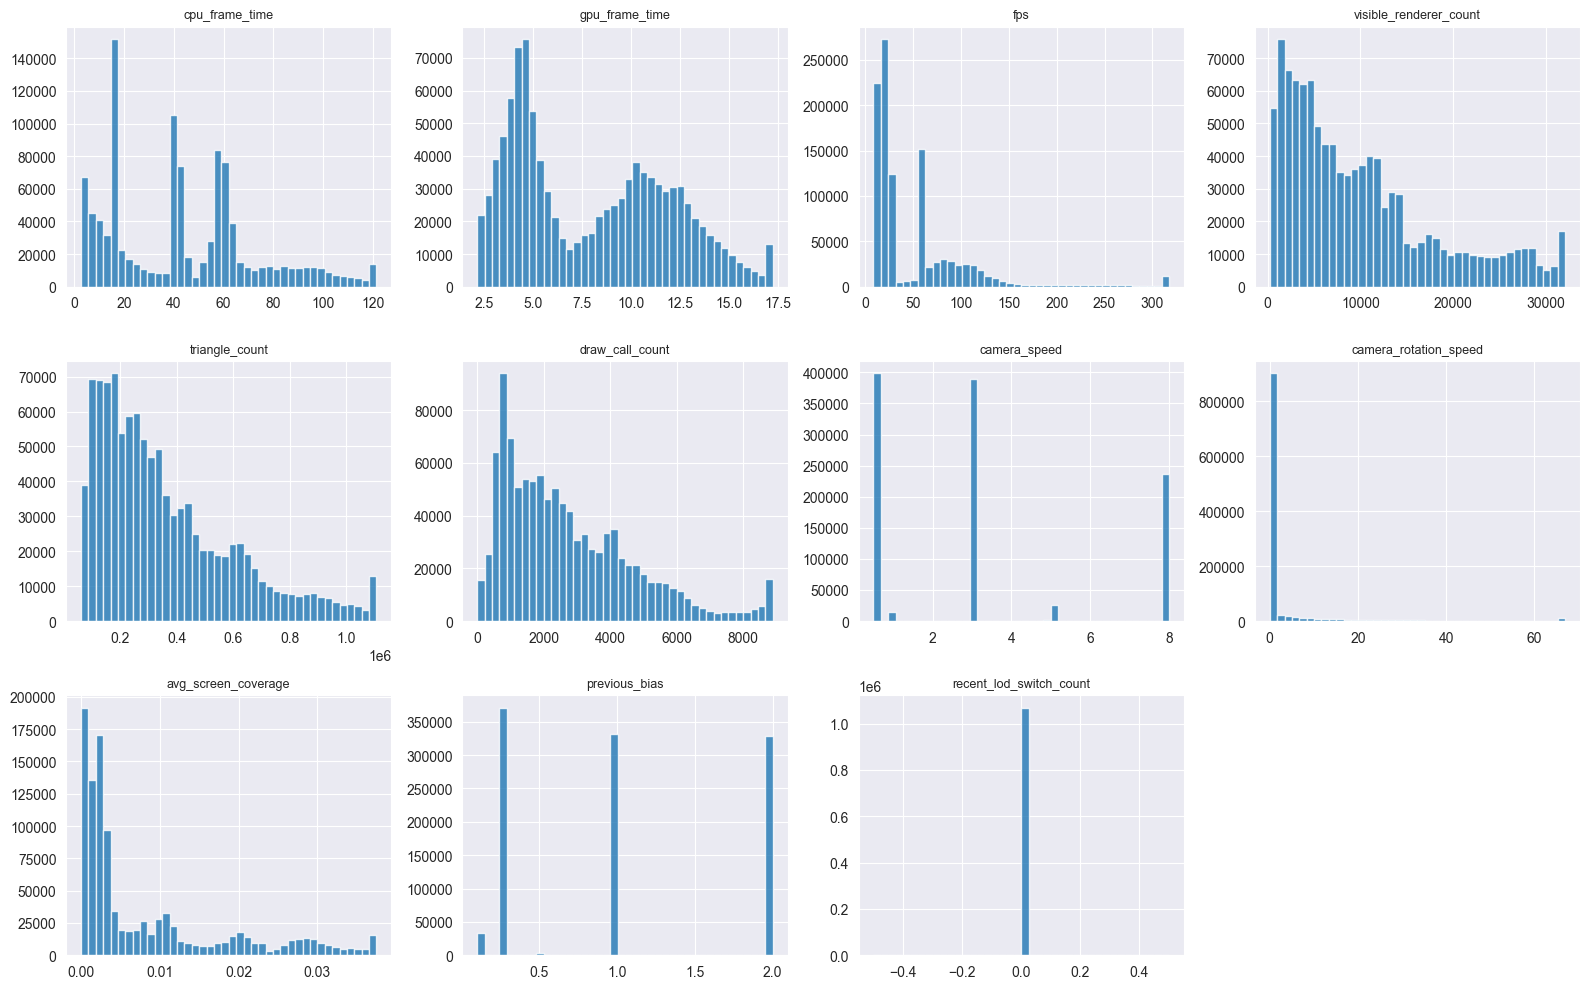

Final rows: 1068720
Episodes: 193


In [19]:
# =========================
# STEP 0: FIX EPISODES (MANDATORY)
# =========================
raw = raw.copy()

if raw['episode'].isna().all():
    print("Fixing missing episode column...")
    raw['episode'] = (raw['step'] == 0).cumsum()

    if raw['episode'].nunique() == 1:
        print("No step reset detected → single episode fallback")
        raw['episode'] = 0

print("Episodes:", raw['episode'].nunique())
print("RAW shape:", raw.shape)

# =========================
# STEP 1: INVALID FILTER
# =========================
df_clean = raw[
    (raw['gpu_frame_time'] > 0) &
    (raw['cpu_frame_time'] > 0)
].copy()

print("After invalid:", df_clean.shape)

if len(df_clean) == 0:
    raise ValueError("All data removed at invalid filter")

# =========================
# STEP 2: OUTLIER CLIP (NO ROW REMOVAL)
# =========================
p99 = df_clean.groupby('episode')['gpu_frame_time'].transform(lambda x: x.quantile(0.99))

print("p99 NaNs:", p99.isna().sum())

df_clean['gpu_frame_time'] = np.minimum(df_clean['gpu_frame_time'], p99)

print("After clip:", df_clean.shape)

# =========================
# STEP 3: NaN DEBUG + SAFE CLEAN
# =========================
nan_counts = df_clean[FEATURE_COLS + ['action_delta']].isna().sum()
print("\nNaN counts:")
print(nan_counts)

# drop only essential features (NOT aggressive)
df_clean = df_clean.dropna(subset=FEATURE_COLS).copy()

print("After dropna:", df_clean.shape)

if len(df_clean) == 0:
    raise ValueError("All data removed at NaN drop")

# =========================
# STEP 4: FINAL CHECK
# =========================
print("FINAL df_clean:", df_clean.shape)

# =========================
# STEP 5: SCALING
# =========================
X_raw = df_clean[FEATURE_COLS].values.astype(np.float32)

if X_raw.shape[0] == 0:
    raise ValueError("No samples available for scaling")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw).astype(np.float32)

print("Scaling OK:", X_scaled.shape)

# =========================
# STEP 6: VALIDATION
# =========================
zero_scale = [
    (name, s)
    for name, s in zip(FEATURE_COLS, scaler.scale_)
    if s < 1e-8
]

if zero_scale:
    print("WARNING zero-scale:", zero_scale)
else:
    print("All feature scales valid")

# =========================
# STEP 7: SAVE SCALER
# =========================
scaler_data = {
    'feature_names': FEATURE_COLS,
    'mean': scaler.mean_.tolist(),
    'scale': scaler.scale_.tolist()
}

scaler_path = MODEL_DIR / 'rl_scaler_constants.json'

with open(scaler_path, 'w') as f:
    json.dump(scaler_data, f, indent=2)

print("Saved:", scaler_path)

# =========================
# STEP 8: FEATURE DISTRIBUTIONS
# =========================
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(FEATURE_COLS):
    col_data = df_clean[col]

    if col_data.notna().sum() == 0:
        axes[i].set_visible(False)
        continue

    clipped = col_data.clip(
        lower=col_data.quantile(0.01),
        upper=col_data.quantile(0.99)
    )

    axes[i].hist(clipped, bins=40, alpha=0.8)
    axes[i].set_title(col, fontsize=9)

for j in range(len(FEATURE_COLS), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'feature_distributions.png', dpi=150)
plt.show()

# =========================
# FINAL SAFETY CHECK
# =========================
print("Final rows:", len(df_clean))
print("Episodes:", df_clean['episode'].nunique())

## 4. Reward Computation
Compute per-step proxy rewards and discounted returns for REINFORCE.

In [20]:
# =========================
# STEP: COMPUTE REWARDS (FIRST)
# =========================
gpu = df_clean['gpu_frame_time'].values
cov = df_clean['avg_screen_coverage'].values.clip(0, 1)
sw  = df_clean['recent_lod_switch_count'].values

frame_term = -ALPHA * ((gpu - T_TARGET) / T_TARGET) ** 2
qual_term  = -BETA  * (1.0 - cov)
stab_term  = -GAMMA_W * (sw / N_MAX).clip(0, 1)

rewards = (frame_term + qual_term + stab_term).astype(np.float32)

# =========================
# VALIDATION (AFTER COMPUTE)
# =========================
if len(rewards) == 0:
    raise ValueError("rewards array is empty → df_clean is empty")

if len(rewards) != len(df_clean):
    raise ValueError("Mismatch: rewards and df_clean size differ")

print(
    f'Reward stats | mean={rewards.mean():.4f} | std={rewards.std():.4f} | '
    f'min={rewards.min():.4f} | max={rewards.max():.4f}'
)

# =========================
# ATTACH TO DF
# =========================
df_clean = df_clean.copy()
df_clean['reward'] = rewards

Reward stats | mean=-1.9165 | std=2.0620 | min=-186.9264 | max=-0.4785


## 5. Policy Network
Gaussian policy MLP.  
- **Input**: 11 normalized state features  
- **Output**: action mean μ (scalar) clamped to [-0.20, +0.20]  
- **log_sigma**: global learned scalar (not part of ONNX output)  
- ONNX exports only μ — Unity reads `output[0]` as the deterministic action

In [21]:
class PolicyMLP(nn.Module):
    """Gaussian policy: outputs action mean mu in [-0.20, +0.20]."""
    def __init__(self, input_dim, h1, h2, h3, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, h1), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(h1, h2),        nn.GELU(), nn.Dropout(dropout),
            nn.Linear(h2, h3),        nn.GELU(),
            nn.Linear(h3, 1),
            nn.Tanh()  # output in (-1, 1)
        )
        self.action_scale = 0.20  # maps tanh output → [-0.20, +0.20]
        # Global log_sigma — not exported to ONNX; used for log_prob during training only
        self.log_sigma = nn.Parameter(torch.zeros(1))

    def forward(self, x):
        """Returns mu. shape: [batch, 1]"""
        return self.net(x) * self.action_scale

    def log_prob(self, x, actions):
        """Gaussian log prob for REINFORCE loss."""
        mu    = self.forward(x)  # [batch, 1]
        sigma = torch.exp(self.log_sigma).clamp(1e-4, 2.0)
        dist  = Normal(mu, sigma)
        return dist.log_prob(actions.unsqueeze(-1)).squeeze(-1)  # [batch]

print('PolicyMLP defined. Verifying output shape...')
_test = PolicyMLP(11, 256, 128, 64, 0.1)
_x    = torch.randn(4, 11)
_out  = _test(_x)
assert _out.shape == (4, 1), f'Expected (4,1) got {_out.shape}'
print(f'Output shape OK: {_out.shape} | range: [{_out.min().item():.3f}, {_out.max().item():.3f}]')

PolicyMLP defined. Verifying output shape...
Output shape OK: torch.Size([4, 1]) | range: [0.005, 0.012]


## 6. Hyperparameter Tuning (Optuna)


Reward Computation and Return Normalization

In [22]:
# =========================
# STEP: REWARD + RETURNS (REQUIRED)
# =========================
if len(df_clean) == 0:
    raise ValueError("df_clean is empty before reward computation")

# --- rewards ---
gpu = df_clean['gpu_frame_time'].values
cov = df_clean['avg_screen_coverage'].values.clip(0, 1)
sw  = df_clean['recent_lod_switch_count'].values

frame_term = -ALPHA * ((gpu - T_TARGET) / T_TARGET) ** 2
qual_term  = -BETA  * (1.0 - cov)
stab_term  = -GAMMA_W * (sw / N_MAX).clip(0, 1)

rewards = (frame_term + qual_term + stab_term).astype(np.float32)

if len(rewards) != len(df_clean):
    raise ValueError("Reward size mismatch")

df_clean = df_clean.copy()
df_clean['reward'] = rewards

# --- returns ---
def compute_returns(rewards_ep, gamma):
    G = np.zeros_like(rewards_ep)
    running = 0.0
    for t in reversed(range(len(rewards_ep))):
        running = rewards_ep[t] + gamma * running
        G[t] = running
    return G

returns_list = []
for _, grp in df_clean.groupby('episode'):
    returns_list.append(compute_returns(grp['reward'].values, GAMMA_RL))

df_clean['G_t'] = np.concatenate(returns_list)

# --- normalize ---
G_mean = df_clean['G_t'].mean()
G_std  = df_clean['G_t'].std() + 1e-8

df_clean['G_t_norm'] = (df_clean['G_t'] - G_mean) / G_std

print("Returns ready:", df_clean['G_t_norm'].shape)

Returns ready: (1068720,)


Quick 10-epoch trials to find best architecture and learning rate.

In [23]:
from sklearn.model_selection import train_test_split

X_all = X_scaled
A_all = df_clean['action_delta'].values.astype(np.float32)
G_all = df_clean['G_t_norm'].values.astype(np.float32)

X_tr, X_val, A_tr, A_val, G_tr, G_val = train_test_split(
    X_all, A_all, G_all, test_size=0.15, random_state=RANDOM_SEED
)

X_tr_t  = torch.tensor(X_tr).to(device)
A_tr_t  = torch.tensor(A_tr).to(device)
G_tr_t  = torch.tensor(G_tr).to(device)
X_val_t = torch.tensor(X_val).to(device)
A_val_t = torch.tensor(A_val).to(device)
G_val_t = torch.tensor(G_val).to(device)

BATCH_SIZE = 256

def reinforce_loss(model, X, A, G):
    """REINFORCE: loss = -mean(G_t_norm * log_prob(a_t | s_t))."""
    lp   = model.log_prob(X, A)   # [batch]
    loss = -(G * lp).mean()
    return loss

def run_trial(h1, h2, h3, lr, dropout, epochs=10):
    model = PolicyMLP(FEATURE_COUNT, h1, h2, h3, dropout).to(device)
    opt   = optim.AdamW(model.parameters(), lr=lr)
    n     = len(X_tr_t)
    for _ in range(epochs):
        model.train()
        idx = torch.randperm(n)
        for start in range(0, n, BATCH_SIZE):
            b = idx[start:start+BATCH_SIZE]
            opt.zero_grad()
            reinforce_loss(model, X_tr_t[b], A_tr_t[b], G_tr_t[b]).backward()
            nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()
    model.eval()
    with torch.no_grad():
        val_loss = reinforce_loss(model, X_val_t, A_val_t, G_val_t).item()
    return val_loss

def objective(trial):
    h1      = trial.suggest_categorical('h1',      [128, 256, 512])
    h2      = trial.suggest_categorical('h2',      [64,  128, 256])
    h3      = trial.suggest_categorical('h3',      [32,  64,  128])
    lr      = trial.suggest_float('lr',            1e-4, 5e-3, log=True)
    dropout = trial.suggest_float('dropout',       0.05, 0.30)
    return run_trial(h1, h2, h3, lr, dropout)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)
print(f'Best val loss: {study.best_value:.6f}')
print(f'Best params:   {study.best_params}')

Best val loss: -899179.062500
Best params:   {'h1': 512, 'h2': 256, 'h3': 64, 'lr': 0.0003463746954146545, 'dropout': 0.050094407311409156}


Best val loss: -899179.062500
Best params:   {'h1': 512, 'h2': 256, 'h3': 64, 'lr': 0.0003463746954146545, 'dropout': 0.050094407311409156}

## 7. Final REINFORCE Training

Epoch   0 | train=-0.0143 | val=-0.0286 | sigma=0.5722
Epoch  25 | train=-894764.8505 | val=-900375.5625 | sigma=0.0001
Epoch  50 | train=-895656.6463 | val=-900845.8750 | sigma=0.0001
Epoch  75 | train=-896586.2084 | val=-901839.6875 | sigma=0.0001
Epoch 100 | train=-896722.4601 | val=-901929.6250 | sigma=0.0001
Epoch 125 | train=-896829.1130 | val=-902056.3750 | sigma=0.0001


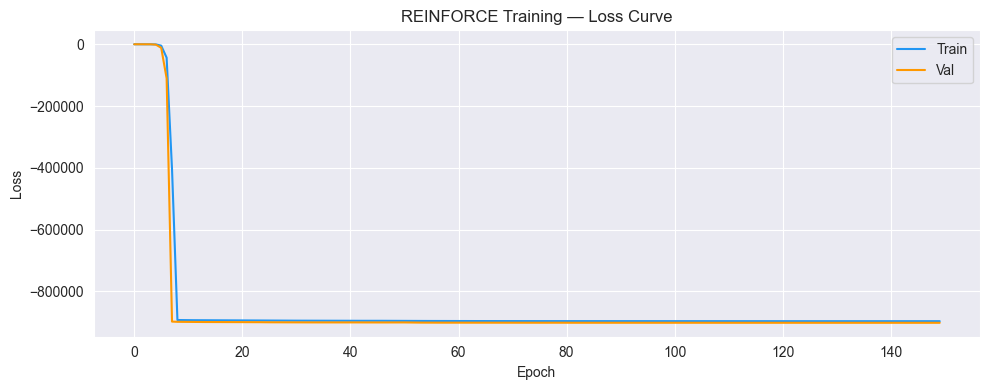

In [24]:
bp = study.best_params
model = PolicyMLP(
    FEATURE_COUNT,
    h1=bp['h1'], h2=bp['h2'], h3=bp['h3'],
    dropout=bp['dropout']
).to(device)

optimizer = optim.AdamW(model.parameters(), lr=bp['lr'])
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=150)

EPOCHS = 150
history = {'train': [], 'val': []}
n = len(X_tr_t)

for epoch in range(EPOCHS):
    model.train()
    idx = torch.randperm(n)
    t_losses = []
    for start in range(0, n, BATCH_SIZE):
        b = idx[start:start+BATCH_SIZE]
        optimizer.zero_grad()
        loss = reinforce_loss(model, X_tr_t[b], A_tr_t[b], G_tr_t[b])
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        t_losses.append(loss.item())
    scheduler.step()

    model.eval()
    with torch.no_grad():
        v_loss = reinforce_loss(model, X_val_t, A_val_t, G_val_t).item()

    history['train'].append(np.mean(t_losses))
    history['val'].append(v_loss)

    if epoch % 25 == 0:
        sigma = torch.exp(model.log_sigma).item()
        print(f'Epoch {epoch:3d} | train={np.mean(t_losses):.4f} | val={v_loss:.4f} | sigma={sigma:.4f}')

# Loss curve
plt.figure(figsize=(10, 4))
plt.plot(history['train'], label='Train', color='#2196F3')
plt.plot(history['val'],   label='Val',   color='#FF9800')
plt.title('REINFORCE Training — Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'loss_curve.png', dpi=150)
plt.show()

## 8. Policy Diagnostics

Learned sigma: 0.0001
Predicted mu   | mean=0.0997 | std=0.0999 | min=-0.2000 | max=0.2000


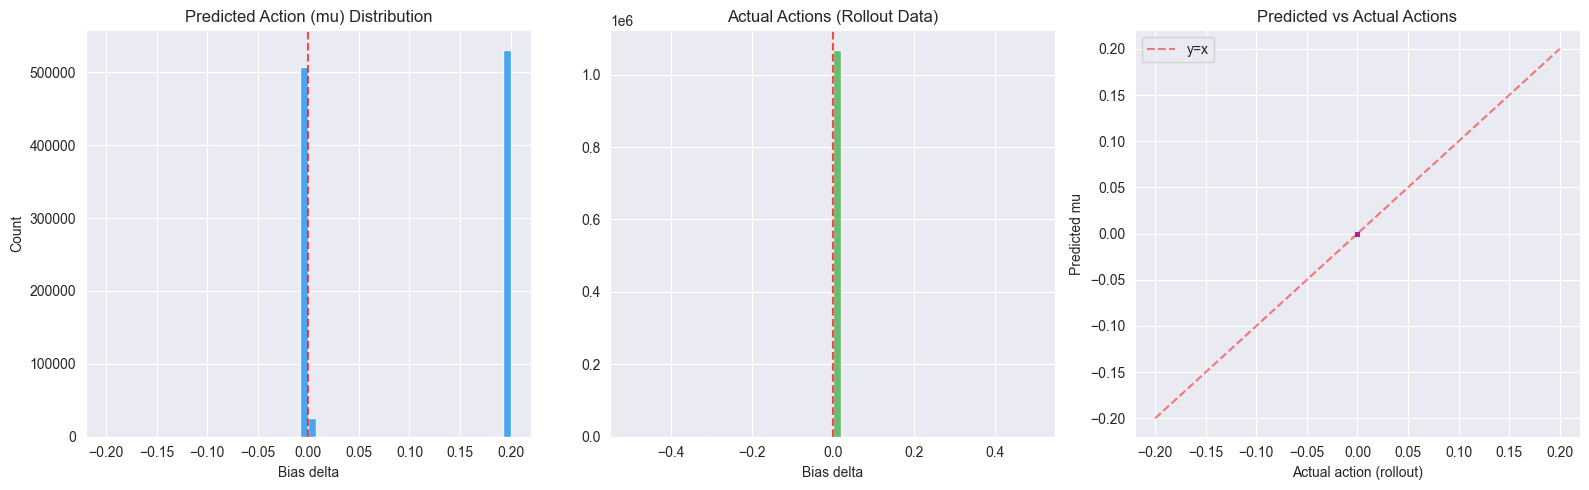

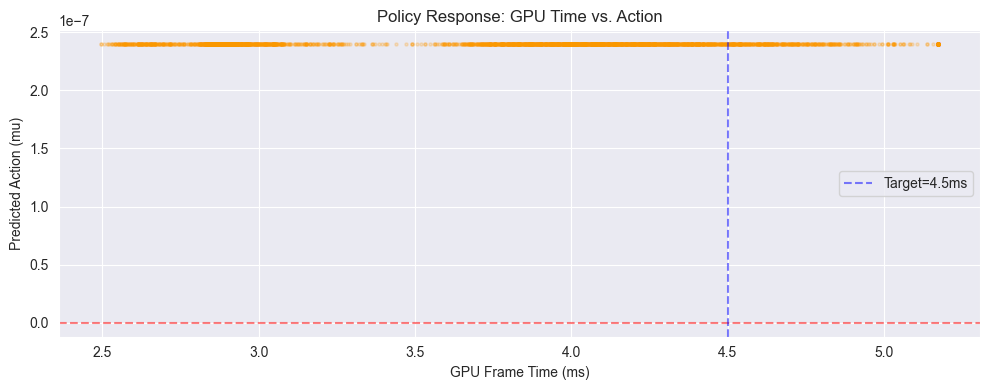

In [25]:
model.eval()
with torch.no_grad():
    mu_all = model(torch.tensor(X_scaled).to(device)).cpu().numpy().flatten()

sigma_val = torch.exp(model.log_sigma).item()
print(f'Learned sigma: {sigma_val:.4f}')
print(f'Predicted mu   | mean={mu_all.mean():.4f} | std={mu_all.std():.4f} | '
      f'min={mu_all.min():.4f} | max={mu_all.max():.4f}')

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Predicted action distribution
ax = axes[0]
ax.hist(mu_all, bins=50, color='#2196F3', alpha=0.8, edgecolor='white')
ax.axvline(0, color='red', linestyle='--', alpha=0.7)
ax.set_title('Predicted Action (mu) Distribution')
ax.set_xlabel('Bias delta')
ax.set_ylabel('Count')

# Actual actions from rollout data
ax = axes[1]
ax.hist(A_all, bins=50, color='#4CAF50', alpha=0.8, edgecolor='white')
ax.axvline(0, color='red', linestyle='--', alpha=0.7)
ax.set_title('Actual Actions (Rollout Data)')
ax.set_xlabel('Bias delta')

# Predicted vs Actual scatter
ax = axes[2]
ax.scatter(A_all[:2000], mu_all[:2000], alpha=0.2, s=5, color='#9C27B0')
ax.plot([-0.2, 0.2], [-0.2, 0.2], 'r--', alpha=0.5, label='y=x')
ax.set_xlabel('Actual action (rollout)')
ax.set_ylabel('Predicted mu')
ax.set_title('Predicted vs Actual Actions')
ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'action_diagnostics.png', dpi=150)
plt.show()

# GPU frame time vs predicted action
plt.figure(figsize=(10, 4))
plt.scatter(df_clean['gpu_frame_time'].values[:3000],
            mu_all[:3000],
            alpha=0.2, s=5, color='#FF9800')
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.axvline(T_TARGET, color='blue', linestyle='--', alpha=0.5, label=f'Target={T_TARGET}ms')
plt.xlabel('GPU Frame Time (ms)')
plt.ylabel('Predicted Action (mu)')
plt.title('Policy Response: GPU Time vs. Action')
plt.legend()
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'policy_response.png', dpi=150)
plt.show()

## 9. ONNX Export
Exports `mu`-only output — Unity `RLPolicyController` reads `output[0]` as the deterministic action mean.

In [26]:
pip install onnxruntime-gpu

Note: you may need to restart the kernel to use updated packages.


In [27]:
import onnxruntime as ort
print(ort.__version__)

1.24.4


In [30]:
FEATURE_COLS = [f for f in FEATURE_COLS if f != 'recent_lod_switch_count']
raw = raw[FEATURE_COLS]

# Rerun quality gate
nonzero_pct = (raw[FEATURE_COLS] != 0).mean() * 100
zero_features = nonzero_pct[nonzero_pct < 1.0].index.tolist()
if zero_features:
    print(f'BLOCKED: {len(zero_features)} features are near-all-zero:')
    for fn in zero_features:
        print(f'  {fn}: {nonzero_pct[fn]:.1f}% non-zero')
    raise RuntimeError('ONNX export blocked — zero-filled features detected.')

print('Quality gate passed. Proceeding with ONNX export.')

Quality gate passed. Proceeding with ONNX export.


In [31]:
class PolicyMLPONNX(nn.Module):
    """Wrapper that strips log_sigma — exports only mu."""
    def __init__(self, policy):
        super().__init__()
        self.net          = policy.net
        self.action_scale = policy.action_scale

    def forward(self, x):
        return self.net(x) * self.action_scale  # [batch, 1]

export_model = PolicyMLPONNX(model).cpu().eval()
dummy_input  = torch.zeros(1, FEATURE_COUNT, dtype=torch.float32)

onnx_path = MODEL_DIR / 'rl_policy_stage4.onnx'
torch.onnx.export(
    export_model,
    dummy_input,
    str(onnx_path),
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch_size'}, 'output': {0: 'batch_size'}},
    opset_version=12
)
print(f'ONNX exported → {onnx_path}')

# Verify output shape with dummy inference
import onnxruntime as ort
sess = ort.InferenceSession(str(onnx_path))
out  = sess.run(None, {'input': dummy_input.numpy()})[0]
print(f'ONNX output shape: {out.shape} | value: {out[0,0]:.6f}')
assert out.shape == (1, 1), f'Expected (1,1), got {out.shape}'
print('ONNX validation OK.')
print(f'\nNext step: assign {onnx_path.name} to RLPolicyController.OnnxAsset in Unity.')

ONNX exported → C:\Users\Gica\neural-lod\ml_pipeline\models\Stage_4\rl_policy_stage4.onnx
ONNX output shape: (1, 1) | value: 0.000000
ONNX validation OK.

Next step: assign rl_policy_stage4.onnx to RLPolicyController.OnnxAsset in Unity.


## 10. Output Summary

In [32]:
print('=== Stage 4 Training Complete ===')
print(f'  Rollout steps used  : {len(df_clean):,}')
print(f'  Episodes            : {df_clean["episode"].nunique()}')
print(f'  Feature count       : {FEATURE_COUNT}')
print(f'  Architecture        : {bp["h1"]}→{bp["h2"]}→{bp["h3"]}→1')
print(f'  Learning rate       : {bp["lr"]:.6f}')
print(f'  Final val loss      : {history["val"][-1]:.6f}')
print(f'  Learned sigma       : {torch.exp(model.log_sigma).item():.4f}')
print()
print(f'  ONNX model          : {MODEL_DIR / "rl_policy_stage4.onnx"}')
print(f'  Scaler JSON         : {MODEL_DIR / "rl_scaler_constants.json"}')
print()
print('Unity setup checklist:')
print('  1. Copy rl_scaler_constants.json → Assets/StreamingAssets/')
print('  2. Import rl_policy_stage4.onnx into Unity project')
print('  3. Assign to RLPolicyController.OnnxAsset')
print('  4. RLFeatureExtractor.scalerJsonFileName = "rl_scaler_constants.json" (default)')
print('  5. Press Play — Active Mode should show "neural" in inspector')

=== Stage 4 Training Complete ===
  Rollout steps used  : 1,068,720
  Episodes            : 193
  Feature count       : 11
  Architecture        : 512→256→64→1
  Learning rate       : 0.000346
  Final val loss      : -902049.625000
  Learned sigma       : 0.0001

  ONNX model          : C:\Users\Gica\neural-lod\ml_pipeline\models\Stage_4\rl_policy_stage4.onnx
  Scaler JSON         : C:\Users\Gica\neural-lod\ml_pipeline\models\Stage_4\rl_scaler_constants.json

Unity setup checklist:
  1. Copy rl_scaler_constants.json → Assets/StreamingAssets/
  2. Import rl_policy_stage4.onnx into Unity project
  3. Assign to RLPolicyController.OnnxAsset
  4. RLFeatureExtractor.scalerJsonFileName = "rl_scaler_constants.json" (default)
  5. Press Play — Active Mode should show "neural" in inspector
